In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [2]:
df = pd.read_csv('placement.csv')
df.head()
new_df = df.copy()
capping_data = df.copy()

In [3]:
df.describe()

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.225000,0.489000
std,0.615898,19.130822,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,100.000000,1.000000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cgpa                  1000 non-null   float64
 1   placement_exam_marks  1000 non-null   float64
 2   placed                1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


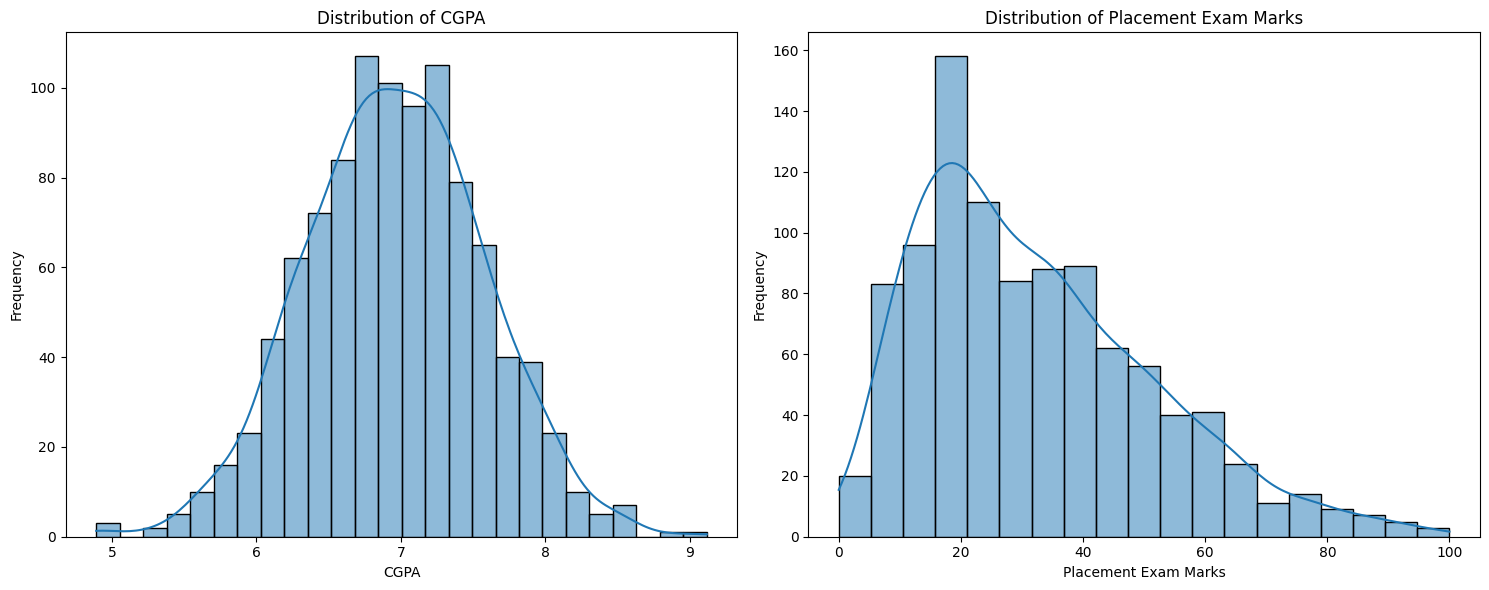

In [5]:
plt.figure(figsize=(15, 6))

# First subplot
plt.subplot(1, 2, 1)
sns.histplot(df['cgpa'], kde=True)
plt.title('Distribution of CGPA')
plt.xlabel('CGPA')
plt.ylabel('Frequency')

# Second subplot
plt.subplot(1, 2, 2)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.title('Distribution of Placement Exam Marks')
plt.xlabel('Placement Exam Marks')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

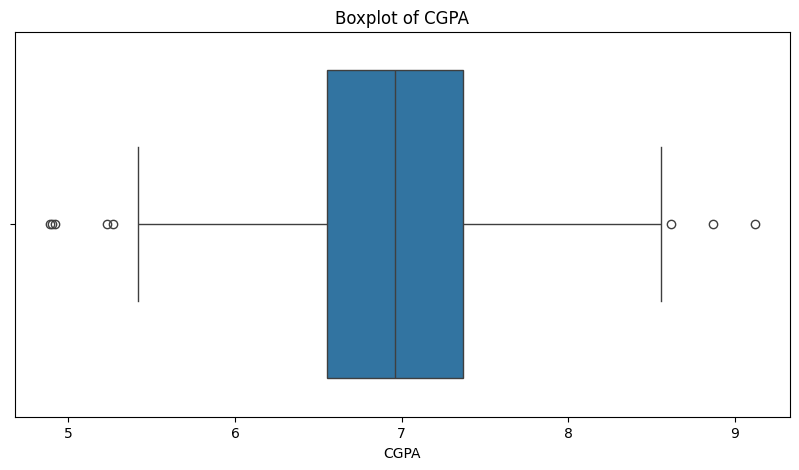

In [6]:
# boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['cgpa'])
plt.title('Boxplot of CGPA')
plt.xlabel('CGPA')
plt.show()


In [7]:
Q1_cgpa = df['cgpa'].quantile(0.25)
print("Q1:", Q1_cgpa)

Q1: 6.55


First Finding the Outlier in the data


In [8]:
# boundary values
# Q1_cgpa = df['cgpa'].quantile(0.25)
# Q3_cgpa = df['cgpa'].quantile(0.75)
# IQR_cgpa = Q3_cgpa - Q1_cgpa
# lower_bound_cgpa = Q1_cgpa - 1.5 * IQR_cgpa
# upper_bound_cgpa = Q3_cgpa + 1.5 * IQR_cgpa
# print(f"CGPA - Lower Bound: {lower_bound_cgpa}, Upper Bound: {upper_bound_cgpa}")


h = df['cgpa'].mean() + 3 * df['cgpa'].std()
l = df['cgpa'].mean() - 3 * df['cgpa'].std()
print(f"CGPA - Lower Bound: {l}, Upper Bound: {h}")

CGPA - Lower Bound: 5.113546374602832, Upper Bound: 8.808933625397168


In [9]:
df[(df['cgpa'] > h) | (df['cgpa'] < l)]


,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


Trimming approach

In [10]:
df = df[~((df['cgpa'] >= h) | (df['cgpa'] <= l))]

In [11]:
df[(df['cgpa'] > h) | (df['cgpa'] < l)]

,cgpa,placement_exam_marks,placed


In [12]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


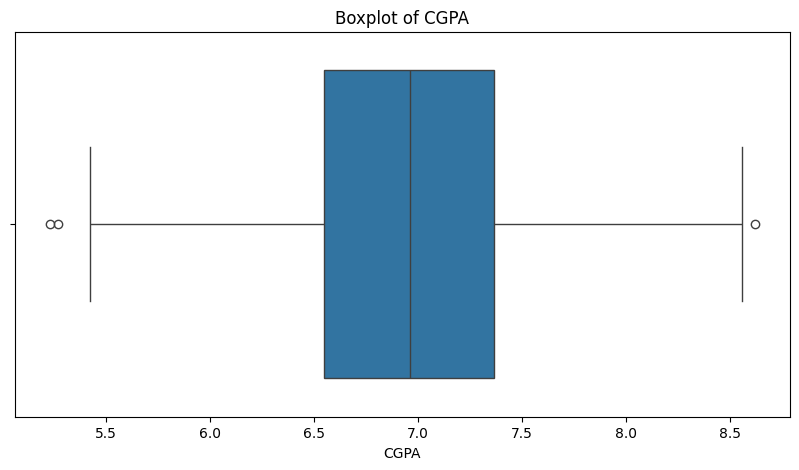

In [13]:
# boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['cgpa'])
plt.title('Boxplot of CGPA')
plt.xlabel('CGPA')
plt.show()


In [14]:
new_df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [15]:
new_df['z_score_cgpa'] = (new_df['cgpa'] - new_df['cgpa'].mean()) / new_df['cgpa'].std()

In [16]:
new_df.head()

,cgpa,placement_exam_marks,placed,z_score_cgpa
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [17]:
new_df[(new_df['z_score_cgpa'] > 3) | (new_df['z_score_cgpa'] < -3)]


,cgpa,placement_exam_marks,placed,z_score_cgpa
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [18]:
new_df = new_df[~((new_df['z_score_cgpa'] > 3) | (new_df['z_score_cgpa'] < -3))]

In [19]:
new_df[(new_df['z_score_cgpa'] > 3) | (new_df['z_score_cgpa'] < -3)]


,cgpa,placement_exam_marks,placed,z_score_cgpa


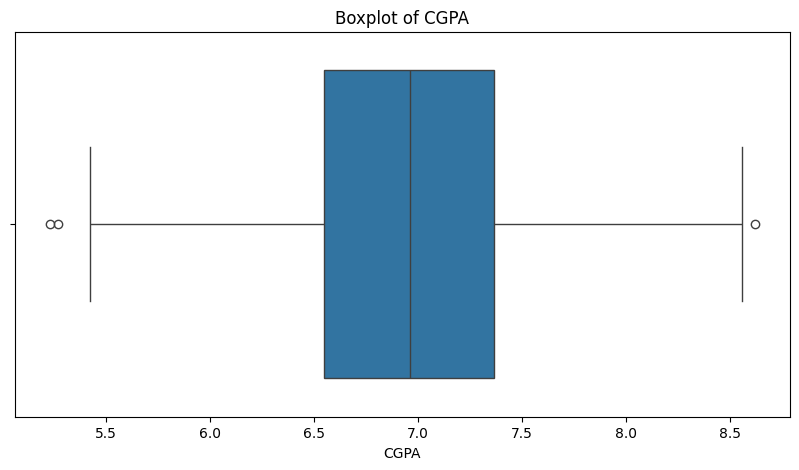

In [20]:
# boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(x=new_df['cgpa'])
plt.title('Boxplot of CGPA')
plt.xlabel('CGPA')
plt.show()


Capping

In [21]:
capping_data.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [22]:
# boundary_ranges

upper_bound_cgpa = capping_data['cgpa'].mean() + 3 * capping_data['cgpa'].std()
lower_bound_cgpa = capping_data['cgpa'].mean() - 3 * capping_data['cgpa'].std()
capping_data[(capping_data['cgpa'] > h) | (capping_data['cgpa'] < l)]


,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [23]:
capping_data['cgpa'] = np.where(
    capping_data['cgpa'] > upper_bound_cgpa,
    upper_bound_cgpa,
    np.where(capping_data['cgpa'] < lower_bound_cgpa, lower_bound_cgpa, capping_data['cgpa'])  
)

In [24]:
capping_data[(capping_data['cgpa'] > h) | (capping_data['cgpa'] < l)]

,cgpa,placement_exam_marks,placed


In [25]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


<Figure size 1500x600 with 0 Axes>

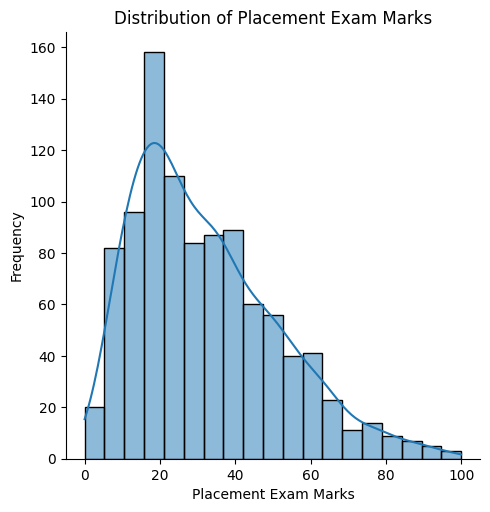

In [26]:
plt.figure(figsize=(15, 6))
sns.displot(df['placement_exam_marks'], kde=True)
plt.title('Distribution of Placement Exam Marks')
plt.xlabel('Placement Exam Marks')
plt.ylabel('Frequency')
plt.show()

In [27]:
q1 = df['placement_exam_marks'].quantile(0.25)
q3 = df['placement_exam_marks'].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f"Placement Exam Marks - Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")

Placement Exam Marks - Lower Bound: -23.50, Upper Bound: 84.50


In [28]:
outlier = df[(df['placement_exam_marks'] > upper_bound) | 
   (df['placement_exam_marks'] < lower_bound)]

outlier.shape[0]

15

Trimming

In [29]:
# new_data_remove_outlier = df[~((df['placement_exam_marks'] > upper_bound) | 
#      (df['placement_exam_marks'] < lower_bound))]

In [30]:
# new_data_remove_outlier.head()

Capping


In [31]:
df['placement_exam_marks'] = np.where(
    df['placement_exam_marks'] > upper_bound,
    upper_bound,
    np.where(df['placement_exam_marks'] < lower_bound, lower_bound, df['placement_exam_marks'])
)

In [32]:
df[(df['placement_exam_marks'] > upper_bound) | 
     (df['placement_exam_marks'] < lower_bound)]

,cgpa,placement_exam_marks,placed
